In [2]:
import matplotlib.pyplot as plt
import os
os.makedirs('output', exist_ok=True)

# 中文显示设置
plt.rcParams['font.sans-serif'] = ['SimHei']
# 防止负号显示为方框
plt.rcParams['axes.unicode_minus'] = False

### 模型模型比较所用公式


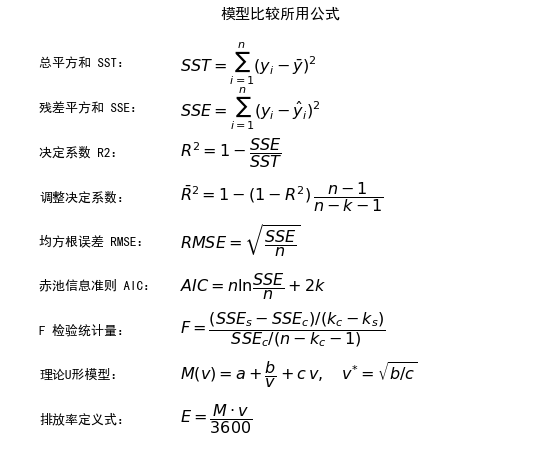

In [ ]:
formulas = [
    ('总平方和 SST',   r'$SST = \sum_{i=1}^{n}(y_i - \bar{y})^2$'),
    ('残差平方和 SSE', r'$SSE = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$'),
    ('决定系数 R2',    r'$R^2 = 1 - \dfrac{SSE}{SST}$'),
    ('调整决定系数',   r'$\bar{R}^2 = 1 - (1-R^2)\,\dfrac{n-1}{n-k-1}$'),
    ('均方根误差 RMSE', r'$RMSE = \sqrt{\dfrac{SSE}{n}}$'),
    ('赤池信息准则 AIC', r'$AIC = n\ln\dfrac{SSE}{n} + 2k$'),
    ('F 检验统计量',   r'$F = \dfrac{(SSE_s - SSE_c)/(k_c - k_s)}{SSE_c/(n - k_c - 1)}$'),
    ('理论U形模型',    r'$M(v) = a + \dfrac{b}{v} + c\,v, \quad v^{*} = \sqrt{b/c}$'),
    ('排放率定义式',   r'$E = \dfrac{M \cdot v}{3600}$'),
]

fig, ax = plt.subplots(figsize=(9, 0.75 * len(formulas) + 1))
ax.axis('off')   # 隐藏坐标轴，只留文字

for i, (title, formula) in enumerate(formulas):
    y = 1 - (i + 0.7) / (len(formulas) + 0.5)
    ax.text(0.02, y, title + '：', fontsize=13, va='center',fontweight='bold')
    ax.text(0.30, y, formula, fontsize=16, va='center')  # 公式

ax.set_title('模型比较所用公式', fontsize=15, pad=14)
fig.savefig('output/模型比较所用公式.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

### F 检验

**复杂模型多出来的参数，带来的拟合改进是否具有统计显著性**

- 分子：从简单模型升级到复杂模型，SSE 下降了多少，除以新增参数个数——每个新参数平均换来多少改进
- 分母：复杂模型的均方残差 SSE_c/(n−k_c−1)——数据本身的噪声水平（σ² 的无偏估计）
- 原假设 H₀：新增参数无作用（复杂模型不比简单模型好）。若 H₀ 为真，F 服从自由度为 (k_c−k_s, n−k_c−1) 的 F 分布
- F 远大于 1 说明新参数带来的改进远超噪声水平 → 拒绝 H₀，复杂模型值得；F 接近 1 说明改进只是噪声 → 保留简单模型（奥卡姆剃刀的统计版）
- 判定规则：p < 0.05 → 显著（新参数有用）；p ≥ 0.05 → 不显著


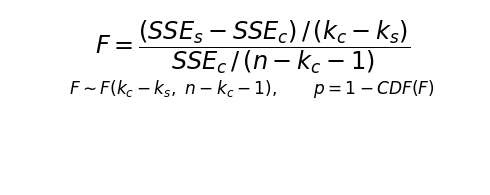

In [13]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')

# 主公式
ax.text(0.5, 0.78,
        r'$F = \dfrac{(SSE_s - SSE_c)\,/\,(k_c - k_s)}{SSE_c\,/\,(n - k_c - 1)}$',
        fontsize=24, ha='center', va='center')

# 分布与 p 值
ax.text(0.5, 0.52,
        r'$F \sim F(k_c - k_s,\ n - k_c - 1), \qquad p = 1 - CDF(F)$',
        fontsize=17, ha='center', va='center')

# 符号说明（中文放在 $...$ 外面，数学符号单独用 mathtext）
# notes = [
    # (0.06, 0.30, '其中：' + r'$SSE_s,\ k_s$' + '：简单模型的残差平方和与参数个数'),
    # (0.06, 0.16, r'$\qquad\ \ SSE_c,\ k_c$' + '：复杂模型的残差平方和与参数个数'),
    # (0.06, 0.02, r'$\qquad\ \ n$' + '：样本量；  判定规则：p < 0.05 则复杂模型显著更优'),
# ]
# for x, y, s in notes:
    # ax.text(x, y, s, fontsize=13, va='center')

# ax.set_title('嵌套模型 F 检验公式', fontsize=15, pad=12)
fig.savefig('output/F检验公式.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()